## Célula 1 — Leitura crua e catalogação dos *light curves* do SPARC4

Varre recursivamente a pasta de dados atrás de todos os arquivos `*_lc.fits` e
abre cada um **sem filtrar, ordenar ou combinar nada**: as colunas saem
exatamente como o *pipeline* gravou. Para cada arquivo, extrai da própria
nomenclatura o **canal/banda** (`_s4c1..4_` → g, r, i, z) e o **feixe**
(`S`, `N`, `S+N`, `S-N` — o SPARC4 é polarimétrico e separa dois feixes).

Cada extensão do FITS corresponde a uma **abertura fotométrica** (`APRADIUS`) e
vira uma entrada no dicionário `aper`, com as colunas, o vetor de tempos, o
número de fontes e a **cadência** (mediana dos intervalos, em segundos).

A tabela impressa serve de **inventário**: o que existe, em que banda, com
quantos pontos, qual cadência e o intervalo UTC de cada série. É a etapa de
inspeção — nada de ciência ainda.

In [1]:
# ═══ leitura crua dos LC do SPARC4 ─ só abre o que existe e cataloga ════════
import glob
import os
import re

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}

arquivos = sorted(glob.glob(os.path.join(BASE, "**", "*_lc.fits"), recursive=True))


def le_lc(arq):
    """Lê um arquivo _lc.fits inteiro: todas as extensões, todas as colunas.

    Nada é filtrado, ordenado ou combinado — as colunas saem como o pipeline
    gravou. Cada extensão vira uma entrada em `aper`, indexada pelo APRADIUS
    do header (ou pelo número da extensão, se o header não trouxer o campo).
    """
    nome = os.path.basename(arq)
    ch   = re.search(r"_s4c(\d)_", nome)
    feix = re.search(r"_(S\+N|S-N|S|N)_lc\.fits$", nome)

    reg = dict(arquivo=nome, caminho=arq, noite=os.path.basename(os.path.dirname(arq)),
               canal=int(ch.group(1)) if ch else None,
               banda=BANDAS.get(int(ch.group(1))) if ch else None,
               feixe=feix.group(1) if feix else None, aper={})

    with fits.open(arq) as h:
        reg["header"] = dict(h[0].header)
        for i, ext in enumerate(h[1:], start=1):
            d = ext.data
            if d is None:
                continue
            cols = {c: np.asarray(d[c]) for c in d.columns.names}
            r = ext.header.get("APRADIUS", i)
            t = np.unique(np.asarray(cols["TIME"], float)) if "TIME" in cols else np.array([])
            reg["aper"][r] = dict(ext=i, colunas=list(cols), n_linhas=len(d), dados=cols,
                                  t=t, n_fontes=np.unique(cols["SRCINDEX"]).size if "SRCINDEX" in cols else 0,
                                  cad=float(np.median(np.diff(t)) * 86400) if t.size > 1 else np.nan)
    return reg


lc = {}
for arq in arquivos:
    r = le_lc(arq)
    lc[(r["noite"], r["banda"], r["feixe"])] = r

print(f"{len(arquivos)} arquivo(s) em {BASE}")
print()
print(f"{'noite':>10} {'banda':>6} {'feixe':>6} {'aper':>5} {'fontes':>7} "
      f"{'pontos':>7} {'cadencia':>10} {'inicio UTC':>11} {'fim UTC':>9}")
for (noite, banda, feixe), r in sorted(lc.items()):
    for a in sorted(r["aper"]):
        e = r["aper"][a]
        if e["t"].size:
            ini = Time(e["t"][0],  format="jd", scale="utc").iso[11:19]
            fim = Time(e["t"][-1], format="jd", scale="utc").iso[11:19]
        else:
            ini = fim = "-"
        print(f"{noite:>10} {str(banda):>6} {str(feixe):>6} {str(a):>5} {e['n_fontes']:>7} "
              f"{e['t'].size:>7} {e['cad']:>9.2f}s {ini:>11} {fim:>9}")

if lc:
    k = sorted(lc)[0]
    a = sorted(lc[k]["aper"])[0]
    print()
    print("colunas disponiveis:", lc[k]["aper"][a]["colunas"])

79 arquivo(s) em C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data

     noite  banda  feixe  aper  fontes  pontos   cadencia  inicio UTC   fim UTC
  20260702      g    S+N     5      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N     8      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    10      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    12      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    15      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    20      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    25      21    8475      2.52s    01:41:02  08:39:32
  20260702      i    S+N     5      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N     8      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N    10      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+

In [ ]:

import glob
import os

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE    = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
DATADIR = os.path.join(BASE, "data")
OUTDIR  = os.path.join(BASE, "resultados_flares")

NOITE  = "20260815"
BEAM   = "S+N"     # soma dos dois feixes: cancela a modulação da lâmina
APER   = 8         # raio da abertura, em pixels
NCOMPS = 3         # nº de comparações: as mais brilhantes depois do alvo

BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}
CORES  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}
LAMBDA = {"g": 457, "r": 614, "i": 753, "z": 894}      # nm, efetivo


def le_bruto(ch, noite=NOITE, aper=APER, ncomps=NCOMPS):
    """Fotometria crua de um canal: alvo, comparações e razão, ponto a ponto.

    O alvo é a fonte mais brilhante do campo e as comparações são as `ncomps`
    seguintes. A razão alvo/Σcomparações é a única conta feita — uma divisão,
    que tira extinção e transparência sem tocar na amostragem. Nenhum ponto é
    descartado por ser outlier: a flare é, por definição, um outlier positivo.
    Só viram NaN os pontos que o próprio pipeline marcou com FLAG.
    """
    padrao = os.path.join(DATADIR, noite, f"*_s4c{ch}_*_{BEAM}_lc.fits")
    arq = sorted(glob.glob(padrao))[0]

    with fits.open(arq) as h:
        ext = [e for e in h[1:] if e.header.get("APRADIUS") == aper][0]
        d = ext.data
        src  = np.asarray(d["SRCINDEX"], float).astype(int)
        t    = np.asarray(d["TIME"], float)          # BJD_UTC
        mag  = np.asarray(d["MAG"], float)
        emag = np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"])

    # (fonte, instante) -> matriz
    idx, t_jd = np.unique(src), np.unique(t)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t_jd, t)
    M = np.full((idx.size, t_jd.size), np.nan)
    E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    ruim = np.zeros(M.shape, bool)
    ruim[lin, col] = np.asarray(flag) != 0
    M[ruim] = np.nan

    ordem = np.argsort(np.nanmedian(M, axis=1))      # do mais brilhante
    ia, ic = ordem[0], ordem[1:1 + ncomps]

    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        e_comp = np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
        razao  = f_alvo / f_comp
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], e_comp / np.where(f_comp > 0, f_comp, np.nan))

    return dict(banda=BANDAS[ch], canal=ch, arquivo=os.path.basename(arq),
                alvo=int(idx[ia]), comps=[int(idx[c]) for c in ic],
                t=t_jd, f_alvo=f_alvo, f_comp=f_comp, razao=razao, sig=e_raz,
                cad=float(np.median(np.diff(t_jd)) * 86400))


bruto = {BANDAS[ch]: le_bruto(ch) for ch in BANDAS}

print(f"noite {NOITE[:4]}-{NOITE[4:6]}-{NOITE[6:]} - feixe {BEAM} - abertura {APER} px")
print()
print(f"{'banda':>6} {'pontos':>8} {'cadencia':>10} {'inicio UTC':>12} {'fim UTC':>10}")
for b, d in bruto.items():
    ini = Time(d["t"][0],  format="jd", scale="utc").iso[11:19]
    fim = Time(d["t"][-1], format="jd", scale="utc").iso[11:19]
    print(f"{b:>6} {d['t'].size:>8} {d['cad']:>9.2f}s {ini:>12} {fim:>10}")

noite 2026-08-15 - feixe S+N - abertura 8 px

 banda   pontos   cadencia   inicio UTC    fim UTC
     g     1938      4.12s     22:34:10   01:16:09
     r     6524      1.32s     22:34:09   01:16:13
     i     6524      1.32s     22:34:09   01:16:13
     z     6524      1.32s     22:34:09   01:16:13


flare F01 - inicio 2026-08-15 22:38:10 TDB = 22:37:00 UTC
duracao 17 min + 2 min de margem de cada lado
janela: 22:35:00 a 22:56:00 UTC

 banda   pontos    t pico        amp   S/R pico
                    [min]      [ppm]
     g      262      1.15     208615       49.6
     r      872      1.98     114439       18.3
     i      872      1.98      71248        8.9
     z      872      1.95      73282        7.1


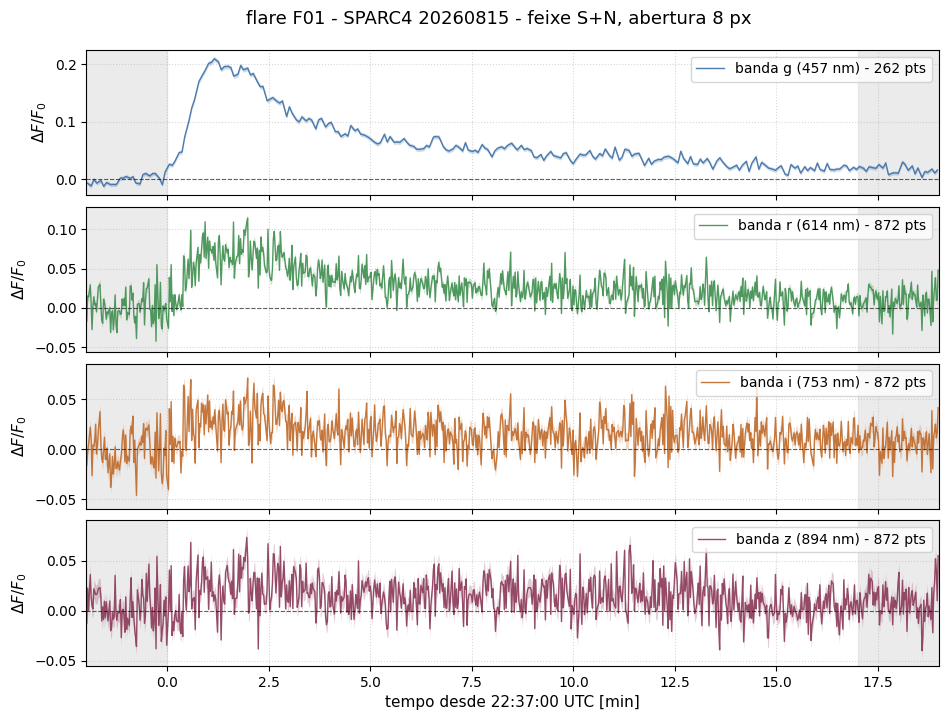

In [3]:
# ═══ 2 · corta a janela da flare e plota ΔF/F₀ nas quatro bandas ════════════
# A janela vem do horário medido da flare (tabela do notebook principal):
# início 22:38:10, 17 min de duração. PAD_MIN acrescenta uma margem de
# quiescente de cada lado — é ela que dá a referência de fluxo fora da flare.
# Cada banda é cortada na SUA grade, sem interpolar para uma grade comum: os
# vetores saem com tamanhos diferentes, e é assim que tem de ser.
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from scipy.stats import sigmaclip

FLARE   = "F01"
INICIO  = "2026-08-15 22:38:10"   # como sai na tabela do notebook principal
ESCALA  = "tdb"                   # ...e essa tabela imprime BJD_TDB, não UTC:
                                  # são 69 s de diferença, mais de um bin. A
                                  # coluna TIME do FITS é BJD_UTC, então o
                                  # horário tem de ser convertido antes do corte.
DUR_MIN = 17                      # duração medida, em minutos
PAD_MIN = 2.0                     # margem de quiescente de cada lado

t0 = Time(INICIO, format="iso", scale=ESCALA).utc.jd   # t = 0 dos vetores
INICIO_UTC = Time(t0, format="jd", scale="utc").iso[11:19]
ja = t0 - PAD_MIN / 1440.0
jb = t0 + (DUR_MIN + PAD_MIN) / 1440.0

flare = {}
for b, d in bruto.items():
    m = (d["t"] >= ja) & (d["t"] <= jb) & np.isfinite(d["razao"])
    t_min = (d["t"][m] - t0) * 1440.0                  # min desde o início
    pre   = d["razao"][m][t_min < 0]
    # nível de repouso: mediana do pré-flare; se a margem não pegou nenhum
    # ponto, cai para sigma-clip assimétrico (corta só o pico positivo).
    base  = float(np.median(pre)) if pre.size else float(
        np.median(sigmaclip(d["razao"][m], low=3.0, high=2.0)[0]))
    flare[b] = dict(
        t_jd   = d["t"][m],          # BJD_UTC, cru
        t_min  = t_min,              # minutos desde o inicio da flare
        razao  = d["razao"][m],      # alvo / soma das comparacoes, cru
        sig    = d["sig"][m],        # erro propagado da fotometria
        f_alvo = d["f_alvo"][m],     # fluxo do alvo, cru
        f_comp = d["f_comp"][m],     # soma das comparacoes, cru
        base   = base,               # nivel pre-flare (referencia, nao aplicado)
        dff    = d["razao"][m] / base - 1.0,   # ΔF/F0, só para o gráfico
        edff   = d["sig"][m] / base,
    )

print(f"flare {FLARE} - inicio {INICIO} {ESCALA.upper()} = {INICIO_UTC} UTC")
print(f"duracao {DUR_MIN:.0f} min + {PAD_MIN:.0f} min de margem de cada lado")
print(f"janela: {Time(ja, format='jd', scale='utc').iso[11:19]} a "
      f"{Time(jb, format='jd', scale='utc').iso[11:19]} UTC")
print()
print(f"{'banda':>6} {'pontos':>8} {'t pico':>9} {'amp':>10} {'S/R pico':>10}")
print(f"{'':>6} {'':>8} {'[min]':>9} {'[ppm]':>10}")
for b, v in flare.items():
    k   = int(np.argmax(v["razao"]))
    amp = (v["razao"][k] / v["base"] - 1.0) * 1e6      # ppm = partes por milhão
    print(f"{b:>6} {v['t_min'].size:>8} {v['t_min'][k]:>9.2f} {amp:>10.0f} "
          f"{(v['razao'][k] - v['base']) / v['sig'][k]:>10.1f}")

# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

# ── gráfico: 4 painéis empilhados, eixo x comum, cada banda na sua grade ────
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"hspace": 0.08})

for ax, b in zip(axes, ["g", "r", "i", "z"]):
    v, cor = flare[b], CORES.get(b, "#333333")
    ax.plot(v["t_min"], v["dff"], color=cor, lw=1.0, alpha=0.9,
            label=f"banda {b} ({LAMBDA[b]} nm) - {v['t_min'].size} pts")
    ax.fill_between(v["t_min"], v["dff"] - v["edff"], v["dff"] + v["edff"],
                    color=cor, alpha=0.25, linewidth=0)
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.axvspan(-PAD_MIN, 0, color="0.85", alpha=0.5, zorder=0)          # pré-flare
    ax.axvspan(DUR_MIN, DUR_MIN + PAD_MIN, color="0.85", alpha=0.5, zorder=0)
    ax.set_ylabel(r"$\Delta F / F_0$", fontsize=11)
    ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.8)
    ax.grid(True, ls=":", alpha=0.5)

axes[-1].set_xlabel(f"tempo desde {INICIO_UTC} UTC [min]", fontsize=11)
axes[-1].set_xlim(-PAD_MIN, DUR_MIN + PAD_MIN)
fig.suptitle(f"flare {FLARE} - SPARC4 {NOITE} - feixe {BEAM}, abertura {APER} px",
             fontsize=13, y=0.93)
plt.show()

In [4]:
import numpy as np, pandas as pd
from scipy.integrate import trapezoid
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson


tf   = pd.read_csv("data/sparc4_spectral_response.csv")
nm   = np.array(tf["Wavelength (nm)"])
ry_g = np.array(tf["Channel g (%)"])/100
ry_r = np.array(tf["Channel r (%)"])/100
ry_i = np.array(tf["Channel i (%)"])/100
ry_z = np.array(tf["Channel z (%)"])/100

Teff, Tflare = 3700, 10000
raio     = 0.75*6.968e+8
Aestrela = np.pi*raio**2
sb1      = 5.670374e-8
n        = 264

# limites por canal (onde a resposta é não-nula)
lambda_min_g, lambda_max_g = nm[ry_g>0].min(), nm[ry_g>0].max()   # 350.0 - 683.3 nm
lambda_min_r, lambda_max_r = nm[ry_r>0].min(), nm[ry_r>0].max()   # 448.5 - 1084.8 nm
lambda_min_i, lambda_max_i = nm[ry_i>0].min(), nm[ry_i>0].max()   # 456.1 - 1100.0 nm
lambda_min_z, lambda_max_z = nm[ry_z>0].min(), nm[ry_z>0].max()   # 539.4 - 1100.0 nm

# grade própria de cada canal
wv_g = np.linspace(lambda_min_g, lambda_max_g, n)
wv_r = np.linspace(lambda_min_r, lambda_max_r, n)
wv_i = np.linspace(lambda_min_i, lambda_max_i, n)
wv_z = np.linspace(lambda_min_z, lambda_max_z, n)

# resposta reamostrada na grade do próprio canal
R_g = np.interp(wv_g, nm, ry_g)
R_r = np.interp(wv_r, nm, ry_r)
R_i = np.interp(wv_i, nm, ry_i)
R_z = np.interp(wv_z, nm, ry_z)

# Planck da estrela e da flare, canal a canal
Bs_g, Bf_g = planck(Teff, lam=wv_g*1.e-9), planck(Tflare, lam=wv_g*1.e-9)
Bs_r, Bf_r = planck(Teff, lam=wv_r*1.e-9), planck(Tflare, lam=wv_r*1.e-9)
Bs_i, Bf_i = planck(Teff, lam=wv_i*1.e-9), planck(Tflare, lam=wv_i*1.e-9)
Bs_z, Bf_z = planck(Teff, lam=wv_z*1.e-9), planck(Tflare, lam=wv_z*1.e-9)



In [5]:
# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
g (fração): 0.201469
g (ppm):    201469 ppm


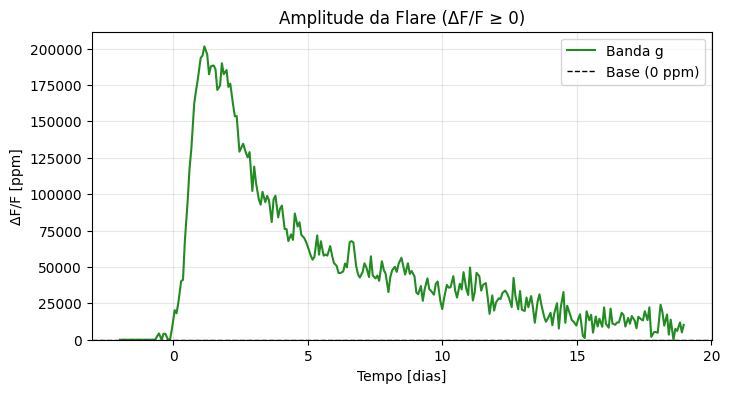

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora = t_g < t_g[np.argmax(C_g)] - 0.02  # ajuste o offset em dias conforme sua curva
a_g = amplitude(t_g, C_g, fora)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_g' perfeitamente alinhado
a_g_pos = np.maximum(a_g, 0)
a_g_ppm_pos = a_g_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos = a_g >= 0
t_g_filtrado = t_g[mask_pos]
a_g_filtrado = a_g[mask_pos]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"g (fração): {np.max(a_g_pos):.6f}")
print(f"g (ppm):    {np.max(a_g_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_g, a_g_ppm_pos, label="Banda g", color="forestgreen")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [dias]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np
from scipy.integrate import simpson

# 1. Normalização e determinação do fluxo de base (quiescente)
base_g = np.median(C_g[fora])
C_norm = C_g / base_g

# 2. Fluxo no pico e Amplitude Relativa ΔF/F
c_max_g = np.max(C_norm)
amp_max_g = c_max_g - 1.0  # max(C - 1)

# 3. Integrais do espectro convoluído com a resposta do filtro
int_estrela = simpson(Bs_g * R_g, wv_g)  # Integral de F_star * S_lambda
int_flare = simpson(Bf_g * R_g, wv_g)  # Integral de B_lambda(T_flare) * S_lambda
int_diff = simpson(
    (Bf_g - Bs_g) * R_g, wv_g
)  # Integral de (B_lambda - F_star) * S_lambda

# 4. Cálculo do Numerador e Denominador da Equação (6)
num = amp_max_g * Aestrela * int_estrela
den = int_diff

# 5. Área final da flare
area = num / den

# =======================================================
# VERIFICAÇÃO PASSO A PASSO DOS VALORES
# =======================================================
print("=== PASSO A PASSO DO CÁLCULO DA ÁREA (BANDA g) ===")
print(f"1. Fluxo quiescente de base (mediana):   {base_g:.6e}")
print(f"2. Fluxo relativo no pico (c_max_g):     {c_max_g:.6f}")
print(f"3. Amplitude relativa max (c_max - 1):   {amp_max_g:.6f}  (ou {amp_max_g * 1e6:.0f} ppm)")
print(f"4. Área projetada da estrela (Aestrela): {Aestrela:.6e} m²")
print(f"5. Integral do fluxo estelar (Bs):       {int_estrela:.6e}")
print(f"6. Integral do fluxo do corpo negro (Bf): {int_flare:.6e}")
print(f"7. Integral da diferença (Bf - Bs):      {int_diff:.6e}")
print("-" * 55)
print(f"TERMO NUMERADOR   (num):                 {num:.6e}")
print(f"TERMO DENOMINADOR (den):                 {den:.6e}")
print("=" * 55)
print(f"ÁREA REAL DA FLARE (A_flare):            {area:.3e} m²")
print(f"FRAÇÃO DO DISCO ESTELAR (A_flare/Astar):  {(area / Aestrela) * 100:.4f}%  (ou {(area / Aestrela) * 1e6:.0f} ppm)")

=== PASSO A PASSO DO CÁLCULO DA ÁREA (BANDA g) ===
1. Fluxo quiescente de base (mediana):   8.289171e+00
2. Fluxo relativo no pico (c_max_g):     1.201469
3. Amplitude relativa max (c_max - 1):   0.201469  (ou 201469 ppm)
4. Área projetada da estrela (Aestrela): 8.580028e+17 m²
5. Integral do fluxo estelar (Bs):       5.243340e+14
6. Integral do fluxo do corpo negro (Bf): 1.171842e+17
7. Integral da diferença (Bf - Bs):      1.166598e+17
-------------------------------------------------------
TERMO NUMERADOR   (num):                 9.063667e+31
TERMO DENOMINADOR (den):                 1.166598e+17
ÁREA REAL DA FLARE (A_flare):            7.769e+14 m²
FRAÇÃO DO DISCO ESTELAR (A_flare/Astar):  0.0906%  (ou 906 ppm)


In [8]:
import numpy as np
from scipy.integrate import simpson

# =======================================================
# PASSO 1: TERMOS BASE E INTEGRAL QUIESCENTE DA ESTRELA
# =======================================================
# Integral de S_lambda * F_star (fluxo da estrela quiescente)
int_estrela = simpson(Bs_g * R_g, wv_g)

# Amplitude máxima no pico (C - 1)
amp_pico = np.max(a_g)  # ou (c_max_g - 1)

# =======================================================
# PASSO 2: CÁLCULO DO LADO DIREITO (RHS) DA EQ. (7) NO PICO
# =======================================================
# Termo 1: Razão de áreas multiplicada pela amplitude
termo_area = (amp_pico * Aestrela) / area  # (C - 1) * A_star / A_flare

# Termo 2: Fator multiplicativo entre parênteses
fator_mult = termo_area + 1.0  # ( (C - 1)*A_star / A_flare + 1 )

# Termo 3: Lado Direito Completo (RHS) da Equação (7)
rhs_pico = fator_mult * int_estrela

# =======================================================
# PASSO 3: VERIFICAÇÃO COM O LADO ESQUERDO (LHS - TEÓRICO)
# =======================================================
# Integral teórica de S_lambda * B_lambda(T_flare_max) a 10.000 K
lhs_teorico = simpson(Bf_g * R_g, wv_g)

# Diferença relativa para validação
diferenca = abs(rhs_pico - lhs_teorico) / lhs_teorico * 100

# =======================================================
# IMPRESSÃO E VERIFICAÇÃO DETALHADA
# =======================================================
print("=== VERIFICAÇÃO PASSO A PASSO DA EQUAÇÃO (7) NO PICO ===")
print(f"1. Amplitude no pico (C - 1):               {amp_pico:.6f}")
print(f"2. Área da Estrela (A_star):                {Aestrela:.6e} m²")
print(f"3. Área da Flare (A_flare):                 {area:.6e} m²")
print(f"4. Termo [(C - 1) * A_star / A_flare]:       {termo_area:.6f}")
print(f"5. Fator Completo [(... ) + 1]:             {fator_mult:.6f}")
print(f"6. Integral Quiescente ∫ S_λ F_star dλ:     {int_estrela:.6e}")
print("-" * 55)
print(f"LADO DIREITO (RHS da Eq. 7 Calculado):       {rhs_pico:.6e}")
print(f"LADO ESQUERDO (LHS Teórico a 10.000 K):      {lhs_teorico:.6e}")
print("-" * 55)
print(f"Diferença relativa entre LHS e RHS:         {diferenca:.8f}%")

=== VERIFICAÇÃO PASSO A PASSO DA EQUAÇÃO (7) NO PICO ===
1. Amplitude no pico (C - 1):               0.201469
2. Área da Estrela (A_star):                8.580028e+17 m²
3. Área da Flare (A_flare):                 7.769313e+14 m²
4. Termo [(C - 1) * A_star / A_flare]:       222.491415
5. Fator Completo [(... ) + 1]:             223.491415
6. Integral Quiescente ∫ S_λ F_star dλ:     5.243340e+14
-------------------------------------------------------
LADO DIREITO (RHS da Eq. 7 Calculado):       1.171842e+17
LADO ESQUERDO (LHS Teórico a 10.000 K):      1.171842e+17
-------------------------------------------------------
Diferença relativa entre LHS e RHS:         0.00000000%


<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\2821294187.py:112: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_g, T_flare_t, color="mediumseagreen", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\2821294187.py:130: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL g (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.201469  (201469 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        7.769313e+14 m²
Fração do Disco Estelar:             0.0906%  (906 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      4.322907e+23 W
                                     4.322907e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.272332e+26 J
 -> Em Ergs:                        1.272332e+33 erg


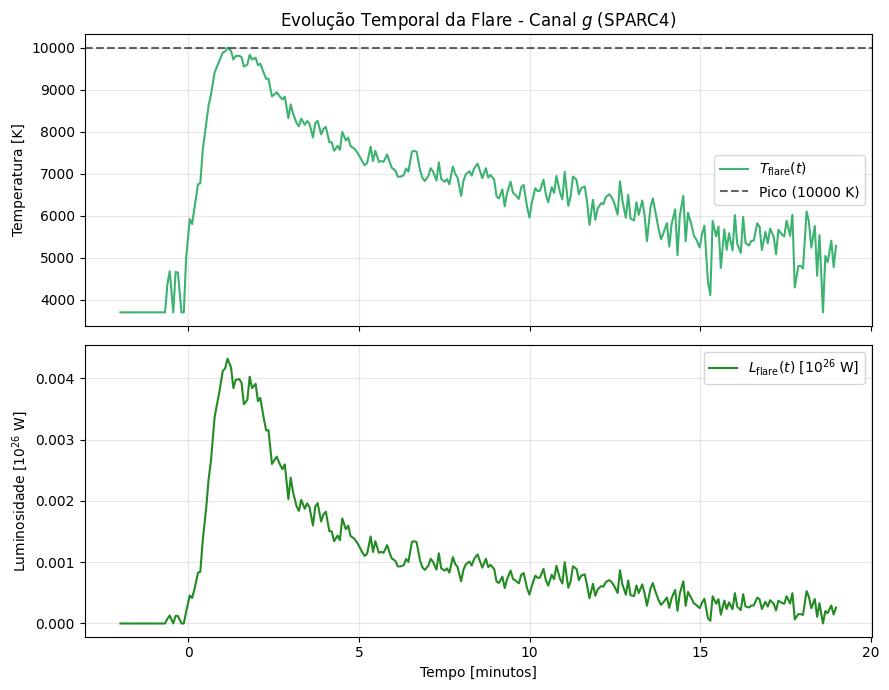

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SEU SETUP INICIAL (SPARC4 - CANAL g)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_g = np.array(tf["Channel g (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal g (350.0 a 683.3 nm) e resposta interpolada
lambda_min_g, lambda_max_g = nm[ry_g > 0].min(), nm[ry_g > 0].max()
wv_g = np.linspace(lambda_min_g, lambda_max_g, n)
R_g = np.interp(wv_g, nm, ry_g)

# ATENÇÃO: Comprimento de onda em METROS para as integrais do Simpson
wv_g_m = wv_g * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_g = planck(Teff, lam=wv_g_m)
Bf_g = planck(Tflare, lam=wv_g_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Supondo a_g = DeltaF/F e t_g em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_g_pos = np.maximum(a_g, 0)
amp_pico = np.max(a_g_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_g * R_g, wv_g_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_g * R_g, wv_g_m)  # Integral do corpo negro da flare
int_diff = simpson(
    (Bf_g - Bs_g) * R_g, wv_g_m
)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_g_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_g_m) * R_g, wv_g_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(
    a_g > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0
)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_g * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL g (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print(f"ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_g, T_flare_t, color="mediumseagreen", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $g$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_g,
    L_flare_t / 1e26,
    color="forestgreen",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
r (fração): 0.096316
r (ppm):    96316 ppm


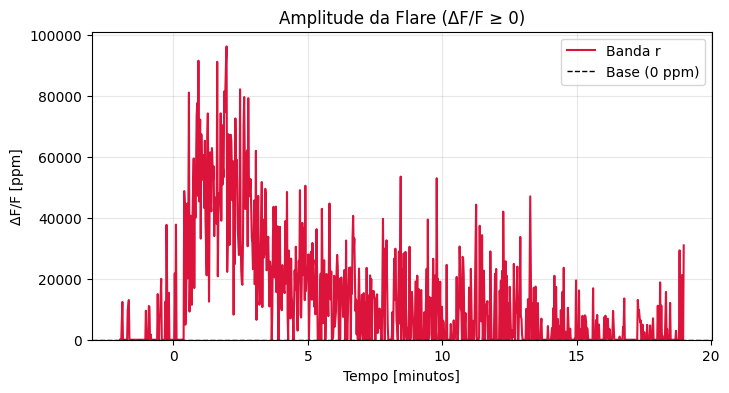

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora = t_r < t_r[np.argmax(C_r)] - 0.02  # ajuste o offset de tempo se necessário
a_r = amplitude(t_r, C_r, fora)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_r' perfeitamente alinhado
a_r_pos = np.maximum(a_r, 0)
a_r_ppm_pos = a_r_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos = a_r >= 0
t_r_filtrado = t_r[mask_pos]
a_r_filtrado = a_r[mask_pos]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"r (fração): {np.max(a_r_pos):.6f}")
print(f"r (ppm):    {np.max(a_r_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_r, a_r_ppm_pos, label="Banda r", color="crimson")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
<>:111: SyntaxWarning: invalid escape sequence '\m'
<>:130: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\2558070715.py:111: SyntaxWarning: invalid escape sequence '\m'
  t_r, T_flare_t, color="crimson", label="$T_{\mathrm{flare}}(t)$"
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\2558070715.py:130: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL r (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.096316  (96316 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        1.358606e+15 m²
Fração do Disco Estelar:             0.1583%  (1583 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      7.559404e+23 W
                                     7.559404e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      9.863395e+25 J
 -> Em Ergs:                        9.863395e+32 erg


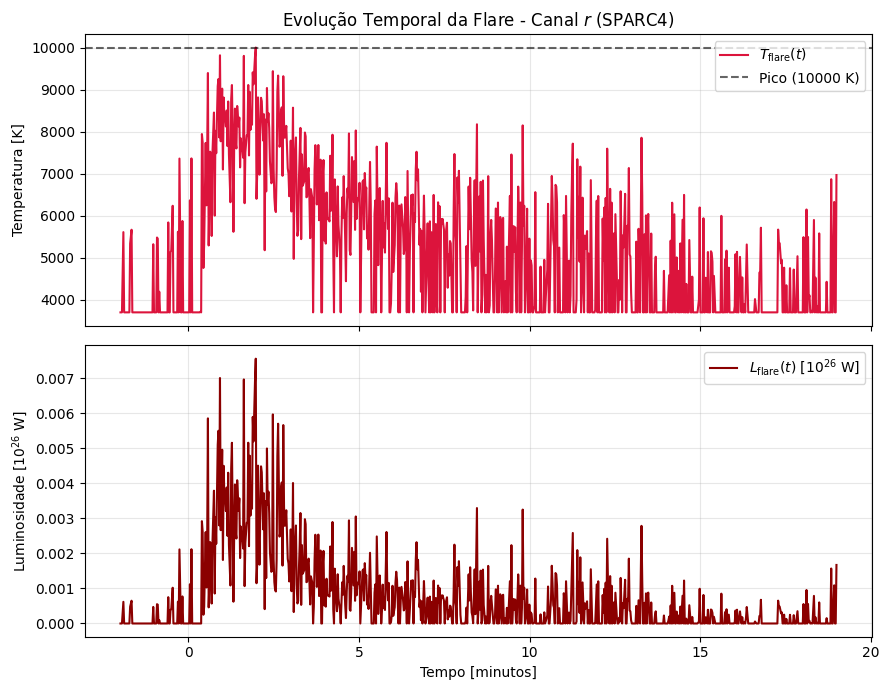

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL r)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_r = np.array(tf["Channel r (%)"]) / 100.0  # Corrigido para Channel r (%)

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal r e resposta interpolada
lambda_min_r, lambda_max_r = nm[ry_r > 0].min(), nm[ry_r > 0].max()
wv_r = np.linspace(lambda_min_r, lambda_max_r, n)
R_r = np.interp(wv_r, nm, ry_r)

# Comprimento de onda em METROS para as integrais do Simpson
wv_r_m = wv_r * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_r = planck(Teff, lam=wv_r_m)
Bf_r = planck(Tflare, lam=wv_r_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_r = DeltaF/F e t_r em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_r_pos = np.maximum(a_r, 0)
amp_pico = np.max(a_r_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_r * R_r, wv_r_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_r * R_r, wv_r_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_r - Bs_r) * R_r, wv_r_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_r_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_r_m) * R_r, wv_r_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(
    a_r > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0
)  # Corrigido para a_r

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_r * 60.0  # Corrigido para t_r

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL r (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print(f"ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(
    t_r, T_flare_t, color="crimson", label="$T_{\mathrm{flare}}(t)$"
)  # Corrigido para t_r
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $r$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_r,
    L_flare_t / 1e26,
    color="darkred",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)  # Corrigido para t_r
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
i (fração): 0.060511
i (ppm):    60511 ppm


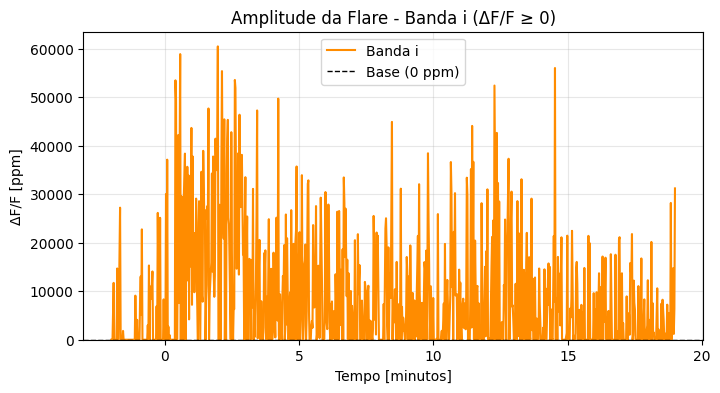

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora_i = t_i < t_i[np.argmax(C_i)] - 0.02  # ajuste o offset de tempo se necessário
a_i = amplitude(t_i, C_i, fora_i)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_i' perfeitamente alinhado
a_i_pos = np.maximum(a_i, 0)
a_i_ppm_pos = a_i_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos_i = a_i >= 0
t_i_filtrado = t_i[mask_pos_i]
a_i_filtrado = a_i[mask_pos_i]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"i (fração): {np.max(a_i_pos):.6f}")
print(f"i (ppm):    {np.max(a_i_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_i, a_i_ppm_pos, label="Banda i", color="darkorange")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare - Banda i (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\3558380772.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_i, T_flare_t, color="darkorange", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\3558380772.py:126: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL i (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.060511  (60511 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        1.732513e+15 m²
Fração do Disco Estelar:             0.2019%  (2019 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      9.639878e+23 W
                                     9.639878e+30 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.146643e+26 J
 -> Em Ergs:                        1.146643e+33 erg


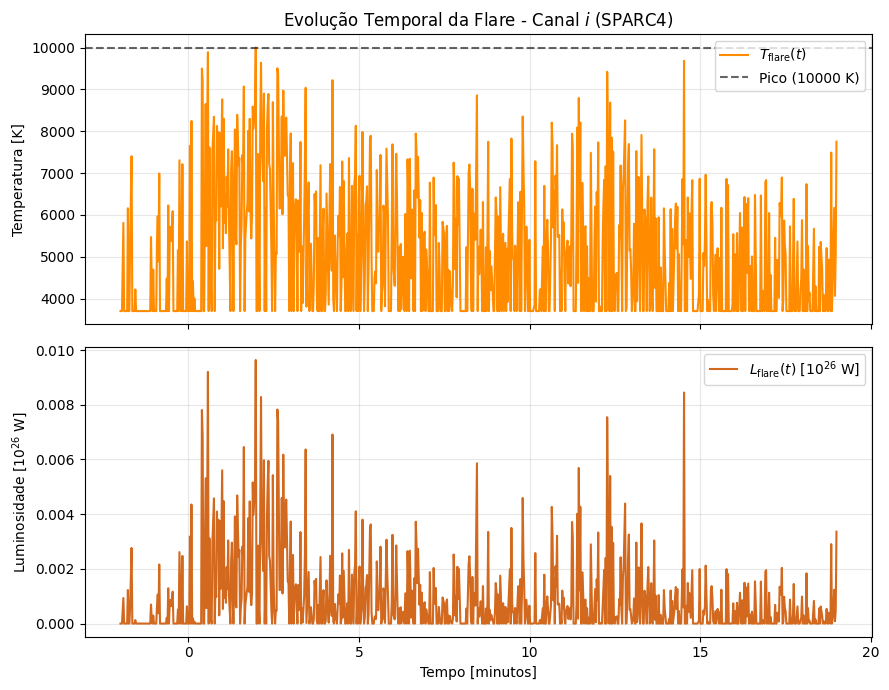

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL i)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_i = np.array(tf["Channel i (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal i e resposta interpolada
lambda_min_i, lambda_max_i = nm[ry_i > 0].min(), nm[ry_i > 0].max()
wv_i = np.linspace(lambda_min_i, lambda_max_i, n)
R_i = np.interp(wv_i, nm, ry_i)

# Comprimento de onda em METROS para as integrais do Simpson
wv_i_m = wv_i * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_i = planck(Teff, lam=wv_i_m)
Bf_i = planck(Tflare, lam=wv_i_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_i = DeltaF/F e t_i em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_i_pos = np.maximum(a_i, 0)
amp_pico = np.max(a_i_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_i * R_i, wv_i_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_i * R_i, wv_i_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_i - Bs_i) * R_i, wv_i_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_i_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 10000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_i_m) * R_i, wv_i_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(a_i > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_i * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL i (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print("ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_i, T_flare_t, color="darkorange", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $i$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_i,
    L_flare_t / 1e26,
    color="chocolate",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:
z (fração): 0.061613
z (ppm):    61613 ppm


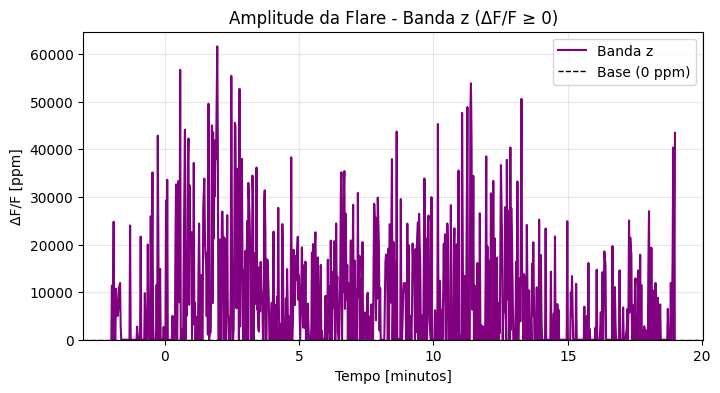

In [14]:
import matplotlib.pyplot as plt
import numpy as np


def amplitude(t, C, fora):  # fora = máscara do trecho quiescente (sem flare)
  base = np.median(C[fora])
  return (C - base) / base


# 1. Definir trecho quiescente e calcular amplitude relativa
fora_z = t_z < t_z[np.argmax(C_z)] - 0.02  # ajuste o offset de tempo se necessário
a_z = amplitude(t_z, C_z, fora_z)

# 2. Filtrar para pegar APENAS da linha para cima (>= 0)
# Trunca o ruído negativo em 0 mantendo o vetor 't_z' perfeitamente alinhado
a_z_pos = np.maximum(a_z, 0)
a_z_ppm_pos = a_z_pos * 1e6

# Caso precise também dos vetores estritamente filtrados (removendo pontos <= 0):
mask_pos_z = a_z >= 0
t_z_filtrado = t_z[mask_pos_z]
a_z_filtrado = a_z[mask_pos_z]

# 3. Exibir Amplitudes Máximas Positivas
print("Amplitude da flare (DeltaF/F) por banda [apenas da linha para cima]:")
print(f"z (fração): {np.max(a_z_pos):.6f}")
print(f"z (ppm):    {np.max(a_z_ppm_pos):.0f} ppm")

# 4. Plotagem em PPM (apenas >= 0)
plt.figure(figsize=(8, 4))
plt.plot(t_z, a_z_ppm_pos, label="Banda z", color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="Base (0 ppm)")
plt.xlabel("Tempo [minutos]")
plt.ylabel("ΔF/F [ppm]")
plt.ylim(bottom=0)  # Ajusta a visualização para começar estritamente no zero
plt.title("Amplitude da Flare - Banda z (ΔF/F ≥ 0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:126: SyntaxWarning: invalid escape sequence '\m'
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\1992380960.py:108: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t_z, T_flare_t, color="purple", label="$T_{\mathrm{flare}}(t)$")
C:\Users\paola\AppData\Local\Temp\ipykernel_29000\1992380960.py:126: SyntaxWarning: invalid escape sequence '\m'
  label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",


=== RESULTADOS DA FLARE NO CANAL z (SPARC4) ===
Amplitude Máxima (ΔF/F):            0.061613  (61613 ppm)
Área Projetada da Estrela (A_star): 8.580028e+17 m²
Área Real da Flare (A_flare):        2.850750e+15 m²
Fração do Disco Estelar:             0.3323%  (3323 ppm)

Temperatura Máxima no Pico:         10000.0 K
Luminosidade Máxima Excedente:      1.586185e+24 W
                                     1.586185e+31 erg/s

ENERGIA BOLOMÉTRICA TOTAL (E_flare):
 -> Em Joules:                      1.498627e+26 J
 -> Em Ergs:                        1.498627e+33 erg


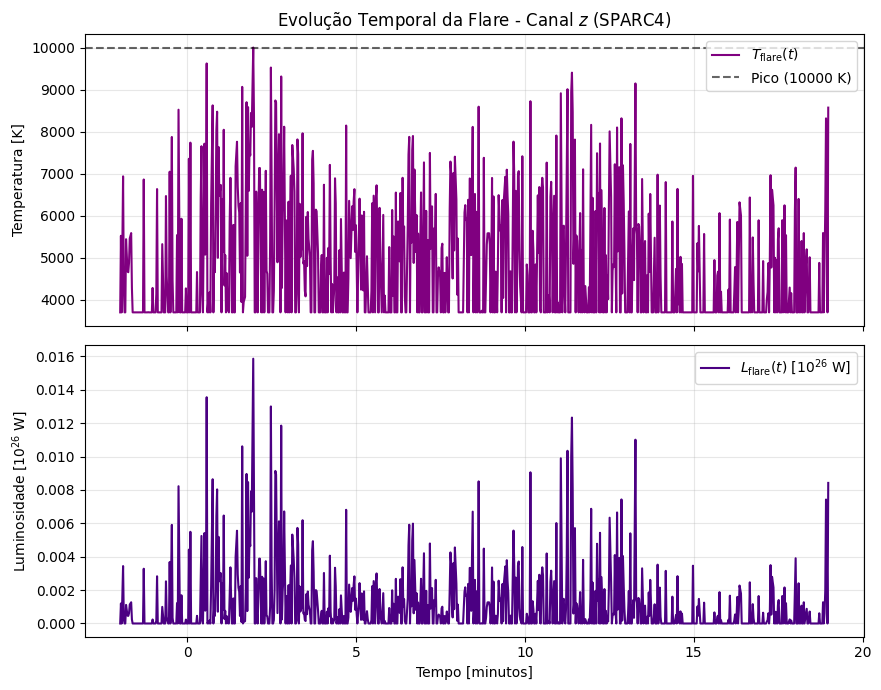

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. SETUP INICIAL (SPARC4 - CANAL z)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])
ry_z = np.array(tf["Channel z (%)"]) / 100.0

Teff, Tflare = 3700, 10000
raio = 0.75 * 6.968e8  # Raio em metros
Aestrela = np.pi * raio**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

# Grade do canal z e resposta interpolada
lambda_min_z, lambda_max_z = nm[ry_z > 0].min(), nm[ry_z > 0].max()
wv_z = np.linspace(lambda_min_z, lambda_max_z, n)
R_z = np.interp(wv_z, nm, ry_z)

# Comprimento de onda em METROS para as integrais do Simpson
wv_z_m = wv_z * 1.0e-9

# Funções de Planck em unidades SI (W m^-2 m^-1 sr^-1) via PyAstronomy
Bs_z = planck(Teff, lam=wv_z_m)
Bf_z = planck(Tflare, lam=wv_z_m)

# ==============================================================================
# 2. TRATAMENTO DA AMPLITUDE (Usando a_z = DeltaF/F e t_z em minutos)
# ==============================================================================
# Trunca o ruído negativo para considerar apenas a emissão erutiva real (>= 0)
a_z_pos = np.maximum(a_z, 0)
amp_pico = np.max(a_z_pos)

# ==============================================================================
# 3. CÁLCULO DA ÁREA DA FLARE (EQUAÇÃO 6)
# ==============================================================================
int_Bs = simpson(Bs_z * R_z, wv_z_m)  # Integral do espectro da estrela
int_Bf = simpson(Bf_z * R_z, wv_z_m)  # Integral do corpo negro da flare
int_diff = simpson((Bf_z - Bs_z) * R_z, wv_z_m)  # Integral da diferença (Bf - Bs)

# Área real fixa da flare
A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

# ==============================================================================
# 4. EVOLUÇÃO TEMPORAL DA TEMPERATURA T_flare(t) (EQUAÇÃO 7)
# ==============================================================================
# Lado Direito (RHS) da Equação (7) para todos os instantes t
rhs_t = ((a_z_pos * Aestrela) / A_flare + 1.0) * int_Bs

# Tabela de Busca (Lookup Table) usando PyAstronomy
T_grid = np.linspace(2000, 25000, 1000)
lhs_grid = np.array(
    [simpson(planck(T, lam=wv_z_m) * R_z, wv_z_m) for T in T_grid]
)

# Interpolação para obter a temperatura em cada instante
T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

# ==============================================================================
# 5. LUMINOSIDADE EXCEDENTE L_flare(t) E ENERGIA TOTAL E_flare (EQS. 8 e 9)
# ==============================================================================
# Luminosidade Bolométrica Excedente (Subtrai a componente quiescente da estrela)
L_flare_t = np.where(a_z > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0)

# Converter tempo de MINUTOS para SEGUNDOS
t_segundos = t_z * 60.0

# Integração temporal da luminosidade para obter a Energia Total
E_flare_J = simpson(L_flare_t, t_segundos)
E_flare_erg = E_flare_J * 1.0e7

# ==============================================================================
# 6. EXIBIÇÃO DETALHADA DOS RESULTADOS
# ==============================================================================
print("=== RESULTADOS DA FLARE NO CANAL z (SPARC4) ===")
print(
    f"Amplitude Máxima (ΔF/F):            {amp_pico:.6f}  ({amp_pico*1e6:.0f}"
    " ppm)"
)
print(f"Área Projetada da Estrela (A_star): {Aestrela:.6e} m²")
print(f"Área Real da Flare (A_flare):        {A_flare:.6e} m²")
print(
    "Fração do Disco Estelar:            "
    f" {(A_flare/Aestrela)*100:.4f}%  ({(A_flare/Aestrela)*1e6:.0f} ppm)\n"
)
print(f"Temperatura Máxima no Pico:         {np.max(T_flare_t):.1f} K")
print(f"Luminosidade Máxima Excedente:      {np.max(L_flare_t):.6e} W")
print(
    "                                    "
    f" {np.max(L_flare_t)*1e7:.6e} erg/s\n"
)
print("ENERGIA BOLOMÉTRICA TOTAL (E_flare):")
print(f" -> Em Joules:                      {E_flare_J:.6e} J")
print(f" -> Em Ergs:                        {E_flare_erg:.6e} erg")
print("=" * 52)

# ==============================================================================
# 7. GRÁFICOS
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gráfico 1: Temperatura
ax1.plot(t_z, T_flare_t, color="purple", label="$T_{\mathrm{flare}}(t)$")
ax1.axhline(
    Tflare,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Pico ({Tflare} K)",
)
ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - Canal $z$ (SPARC4)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Luminosidade
ax2.plot(
    t_z,
    L_flare_t / 1e26,
    color="indigo",
    label="$L_{\mathrm{flare}}(t)$ [$10^{26}$ W]",
)
ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. PARÂMETROS E SETUP INICIAL DA ESTRELA
# ==============================================================================
Teff, Tflare = 3700, 10000  # Temperatura quiescente e do pico da flare [K]
raio = 0.75 * 6.968e8  # Raio estelar [m]
Aestrela = np.pi * raio**2  # Área projetada da estrela [m²]
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W/(m² K⁴)]
n = 264  # Resolução da grade espectral

# Leitura do arquivo de resposta espectral do SPARC4
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])

# Dicionários com os vetores de tempo e amplitude de entrada de cada canal
# (Certifique-se de que t_g, a_g, t_r, a_r, t_i, a_i, t_z, a_z já estejam definidos)
dados_entrada = {
    "g": {"t": t_g, "a": a_g, "col_csv": "Channel g (%)"},
    "r": {"t": t_r, "a": a_r, "col_csv": "Channel r (%)"},
    "i": {"t": t_i, "a": a_i, "col_csv": "Channel i (%)"},
    "z": {"t": t_z, "a": a_z, "col_csv": "Channel z (%)"},
}

# Tabela de busca (Lookup Table) para interpolação da Temperatura
T_grid = np.linspace(2000, 25000, 1000)

# ==============================================================================
# 2. CÁLCULO FÍSICO CANAL A CANAL
# ==============================================================================
resultados = {}

for ch, d in dados_entrada.items():
  t_ch = d["t"]
  a_ch = d["a"]

  # Resposta Espectral do Canal
  ry = np.array(tf[d["col_csv"]]) / 100.0
  lambda_min, lambda_max = nm[ry > 0].min(), nm[ry > 0].max()
  wv = np.linspace(lambda_min, lambda_max, n)
  R_ch = np.interp(wv, nm, ry)
  wv_m = wv * 1.0e-9  # Metros

  # Funções de Planck (SI)
  Bs = planck(Teff, lam=wv_m)
  Bf = planck(Tflare, lam=wv_m)

  # Amplitude truncada em zero para emissão real
  a_pos = np.maximum(a_ch, 0)
  amp_pico = np.max(a_pos)
  a_ppm_pos = a_pos * 1e6

  # Integrais do espectro (Eq. 6)
  int_Bs = simpson(Bs * R_ch, wv_m)
  int_Bf = simpson(Bf * R_ch, wv_m)
  int_diff = simpson((Bf - Bs) * R_ch, wv_m)

  # Área real fixa da flare
  A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

  # Evolução Temporal da Temperatura T_flare(t) (Eq. 7)
  rhs_t = ((a_pos * Aestrela) / A_flare + 1.0) * int_Bs
  lhs_grid = np.array([simpson(planck(T, lam=wv_m) * R_ch, wv_m) for T in T_grid])
  T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

  # Armazena os resultados processados
  resultados[ch] = {
      "t": t_ch,
      "T": T_flare_t,
      "ppm": a_ppm_pos,
      "A_flare": A_flare,
      "A_ppm": (A_flare / Aestrela) * 1e6,
  }

# ==============================================================================
# 3. PLOTAGEM PAINEL MULTI-CANAL 4x2 (ESTILO ARTIGO CIENTÍFICO)
# ==============================================================================
fig, axes = plt.subplots(
    nrows=4, ncols=2, figsize=(11, 16), dpi=150, sharex=False
)
plt.subplots_adjust(hspace=0.28, wspace=0.22)

# Estilo global de ticks (ApJ / A&A style)
for ax in axes.flat:
  ax.tick_params(
      axis="both",
      which="both",
      direction="in",
      top=True,
      right=True,
      labelsize=9,
  )
  ax.minorticks_on()

canais_ordem = ["g", "r", "i", "z"]

for i, ch in enumerate(canais_ordem):
  ax_left = axes[i, 0]
  ax_right = axes[i, 1]

  res = resultados[ch]
  t_data = res["t"]
  T_data = res["T"]
  ppm_data = res["ppm"]

  # --------------------------------------------------------------------------
  # PAINEL DA ESQUERDA: EVOLUÇÃO DA TEMPERATURA + GRADIENTE
  # --------------------------------------------------------------------------
  T_max = np.max(T_data)

  # Envelope / degradê colorido no fundo
  cmap = cm.coolwarm
  norm = mcolors.Normalize(vmin=4000, vmax=20000)
  factors = np.linspace(0.3, 1.8, 35)

  for factor in factors:
    T_layer = Teff + (T_data - Teff) * factor
    color_val = cmap(norm(Teff + (T_max - Teff) * factor))
    ax_left.plot(t_data, T_layer, color=color_val, alpha=0.15, lw=1.2)

  # Curva principal do Best Fit (Magenta)
  ax_left.plot(
      t_data,
      T_data,
      color="#ff00eb",
      lw=2.2,
      label=f"Best fit {int(T_max)} ± {int(np.std(T_data))} K",
  )

  # Colorbar embutido
  cax = ax_left.inset_axes([0.45, 0.62, 0.48, 0.04])
  sm = cm.ScalarMappable(cmap=cmap, norm=norm)
  sm.set_array([])
  cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
  cb.ax.tick_params(labelsize=7, direction="in")
  cb.set_ticks([4000, 9300, 14600, 19900])

  ax_left.text(
      0.05,
      0.88,
      f"({ch})",
      transform=ax_left.transAxes,
      fontsize=10,
      fontweight="bold",
  )
  ax_left.set_ylabel("Temperature [K]", fontsize=10, fontweight="bold")
  ax_left.legend(
      loc="upper right", frameon=False, fontsize=8, bbox_to_anchor=(0.98, 0.95)
  )
  ax_left.set_ylim(2000, 20500)

  # --------------------------------------------------------------------------
  # PAINEL DA DIREITA: ÁREA / AMPLITUDE PPM
  # --------------------------------------------------------------------------
  mask_pos = ppm_data > 0
  ruido_est = np.std(ppm_data[mask_pos]) * 0.3 if np.any(mask_pos) else 50

  # 1. Pontos medidos (Cinza)
  ax_right.errorbar(
      t_data[::2],
      ppm_data[::2],
      yerr=ruido_est,
      fmt="o",
      color="gray",
      alpha=0.35,
      ms=3.5,
      capsize=2,
      elinewidth=0.8,
      label="Measured area",
  )

  # 2. Binagem temporal (Azul)
  n_bins = 15
  bin_size = max(1, len(t_data) // n_bins)
  t_bin = [
      np.mean(t_data[k : k + bin_size])
      for k in range(0, len(t_data), bin_size)
  ]
  ppm_bin = [
      np.mean(ppm_data[k : k + bin_size])
      for k in range(0, len(ppm_data), bin_size)
  ]
  err_bin = [
      np.std(ppm_data[k : k + bin_size]) / np.sqrt(bin_size) + (ruido_est * 0.2)
      for k in range(0, len(ppm_data), bin_size)
  ]

  ax_right.errorbar(
      t_bin,
      ppm_bin,
      yerr=err_bin,
      fmt="o",
      color="blue",
      ecolor="blue",
      ms=4.5,
      capsize=3,
      label="Rebinned area",
  )

  # 3. Média e Faixa de Incerteza (Vermelho)
  mean_ppm = (
      np.mean(ppm_data[mask_pos]) if np.any(mask_pos) else np.mean(ppm_data)
  )
  std_ppm = (
      np.std(ppm_data[mask_pos]) if np.any(mask_pos) else np.std(ppm_data)
  )

  ax_right.axhline(
      mean_ppm,
      color="tab:red",
      lw=1.5,
      label=f"Mean area: {int(mean_ppm)} ± {int(std_ppm)} PPM",
  )
  ax_right.axhspan(
      mean_ppm - std_ppm,
      mean_ppm + std_ppm,
      color="tab:red",
      alpha=0.2,
      lw=0,
  )

  ax_right.text(
      0.05,
      0.88,
      f"({ch})",
      transform=ax_right.transAxes,
      fontsize=10,
      fontweight="bold",
  )
  ax_right.set_ylabel("Area [PPM]", fontsize=10, fontweight="bold")
  ax_right.legend(loc="upper right", frameon=False, fontsize=8)

  # Eixo X apenas na última linha
  if i == 3:
    ax_left.set_xlabel("Time [min]", fontsize=10, fontweight="bold")
    ax_right.set_xlabel("Time [min]", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson
from scipy.optimize import minimize_scalar

# ==============================================================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS FILTROS (g, r, i, z)
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])

canais = ["g", "r", "i", "z"]
filtros = {}
Teff = 3700  # Temperatura estelar quiescente
n_pts = 300

for c in canais:
    ry = np.array(tf[f"Channel {c} (%)"]) / 100.0
    l_min, l_max = nm[ry > 0].min(), nm[ry > 0].max()
    wv_m = np.linspace(l_min, l_max, n_pts) * 1.0e-9
    R = np.interp(wv_m * 1.0e9, nm, ry)

    # Fluxo quiescente de repouso da estrela no filtro c
    I_star = simpson(planck(Teff, lam=wv_m) * R, wv_m)

    filtros[c] = {"wv_m": wv_m, "R": R, "I_star": I_star}

# ==============================================================================
# 2. TABELA DE BUSCA (LOOKUP TABLE) PARA ACELERAR O CHI-QUADRADO
# ==============================================================================
T_grid = np.linspace(3800, 45000, 1000)  # Grade de temperaturas físicas
m_grid = {c: np.zeros(len(T_grid)) for c in canais}

for idx, T in enumerate(T_grid):
    for c in canais:
        wv_m = filtros[c]["wv_m"]
        R = filtros[c]["R"]
        I_star = filtros[c]["I_star"]

        B_diff = planck(T, lam=wv_m) - planck(Teff, lam=wv_m)
        m_grid[c][idx] = simpson(B_diff * R, wv_m) / I_star


# ==============================================================================
# 3. FUNÇÃO DE AJUSTE FISICAMENTE CORRETO A CADA INSTANTE
# ==============================================================================
def estimar_parametros_instantaneos(a_obs_t, err_obs_t):
    """Ajusta T_flare e f_area minimizando o Chi-quadrado entre os 4 canais do SPARC4."""

    def chi2_temp(T):
        # Interpola m_X(T) da tabela para cada canal
        m_T = {
            c: np.interp(T, T_grid, m_grid[c])
            for c in canais
            if err_obs_t[c] > 0
        }

        # Cálculo da Área Ótima por Mínimos Quadrados Ponderados
        num = sum(
            (a_obs_t[c] * m_T[c]) / (err_obs_t[c] ** 2)
            for c in m_T
            if err_obs_t[c] > 0
        )
        den = sum(
            (m_T[c] ** 2) / (err_obs_t[c] ** 2)
            for c in m_T
            if err_obs_t[c] > 0
        )

        if den == 0:
            return 1e9

        f_area_opt = max(num / den, 0.0)

        # Cálculo do Chi-quadrado
        chi2 = sum(
            ((a_obs_t[c] - f_area_opt * m_T[c]) / err_obs_t[c]) ** 2
            for c in m_T
            if err_obs_t[c] > 0
        )
        return chi2

    # Minimização restrita a um intervalo fisicamente válido
    res = minimize_scalar(chi2_temp, bounds=(3800, 45000), method="bounded")
    T_best = res.x

    # Área final com o T ótimo
    m_T_best = {c: np.interp(T_best, T_grid, m_grid[c]) for c in canais}
    num = sum(
        (a_obs_t[c] * m_T_best[c]) / (err_obs_t[c] ** 2) for c in canais
    )
    den = sum((m_T_best[c] ** 2) / (err_obs_t[c] ** 2) for c in canais)
    f_area_best = max(num / den, 0.0) if den > 0 else 0.0

    return T_best, f_area_best


# ==============================================================================
# 4. LOOP TEMPORAL (Exemplo com arrays de curvas de luz a_t e erros err_t)
# ==============================================================================
# Supondo que você tenha a_t['g'], a_t['r'], a_t['i'], a_t['z'] e seus erros
num_pontos = len(a_t["g"])
T_flare_real = np.zeros(num_pontos)
f_area_real = np.zeros(num_pontos)

for t in range(num_pontos):
    # Dicionário do instante t
    a_obs_t = {c: a_t[c][t] for c in canais}
    err_obs_t = {c: err_t[c][t] for c in canais}

    # Se a emissão for muito fraca em todos os canais (sem flare real)
    if all(a_obs_t[c] <= 0 for c in canais):
        T_flare_real[t] = Teff
        f_area_real[t] = 0.0
    else:
        T, f_a = estimar_parametros_instantaneos(a_obs_t, err_obs_t)
        T_flare_real[t] = T
        f_area_real[t] = f_a

A_star = np.pi * (0.75 * 6.968e8) ** 2  # Área da estrela em m²
A_flare_m2 = f_area_real * A_star

NameError: name 'a_t' is not defined

Banda  | Área Flare (m²)  | T Max (K)  | Energia (Joules) | Energia (Ergs) 
  g    |       7.7693e+14 |    10000.0 |      1.2723e+26 |      1.2723e+33
  r    |       1.3586e+15 |    10000.0 |      9.8634e+25 |      9.8634e+32
  i    |       1.7325e+15 |    10000.0 |      1.1466e+26 |      1.1466e+33
  z    |       2.8507e+15 |    10000.0 |      1.4986e+26 |      1.4986e+33


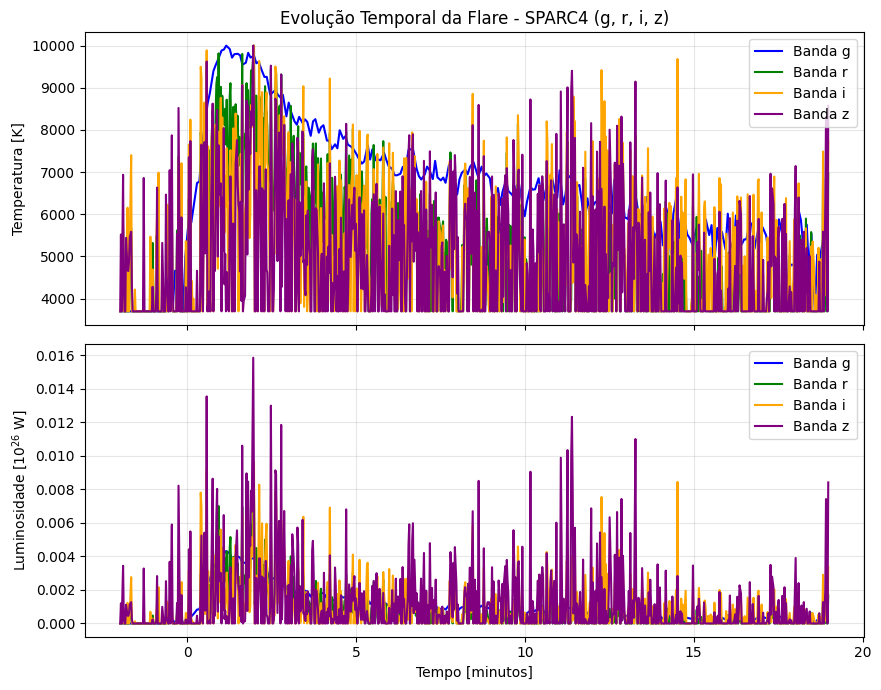

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. PARÂMETROS GERAIS E ESTELARES
# ==============================================================================
Teff = 3700  # Temperatura da estrela (K)
Tflare = 10000  # Temperatura assumida no pico da flare (K)
raio_estrela = 0.75 * 6.968e8  # Raio estelar em metros
Aestrela = np.pi * raio_estrela**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264  # Resolução da grade de comprimento de onda

bandas = ["g", "r", "i", "z"]

# Carrega a resposta espectral contendo os 4 canais
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])

# ==============================================================================
# 2. ENTRADA DOS DADOS DAS 4 BANDAS (E SEUS RESPECTIVOS TEMPOS)
# ==============================================================================
# Curvas de luz (ΔF/F)
curvas_luz = {"g": a_g, "r": a_r, "i": a_i, "z": a_z}

# Vetores de tempo correspondentes a cada banda (em minutos)
# Se suas variáveis de tempo tiverem outro nome (ex: t_g, t_r...), ajuste aqui:
tempos_minutos = {
    "g": t_g if "t_g" in locals() else t_z,
    "r": t_r if "t_r" in locals() else t_z,
    "i": t_i if "t_i" in locals() else t_z,
    "z": t_z,
}

# ==============================================================================
# 3. CÁLCULO DA ENERGIA PARA AS 4 BANDAS (LOOP MULTIBANDA)
# ==============================================================================
resultados = {}

for banda in bandas:
    # 1. Recupera o vetor de dados e o tempo específico desta banda
    y_banda = curvas_luz[banda]
    t_min = tempos_minutos[banda]
    t_seg = t_min * 60.0  # Converte tempo da banda para segundos

    # 2. Carrega a resposta espectral do canal atual
    ry = np.array(tf[f"Channel {banda} (%)"]) / 100.0
    lambda_min = nm[ry > 0].min()
    lambda_max = nm[ry > 0].max()

    wv_nm = np.linspace(lambda_min, lambda_max, n)
    R_banda = np.interp(wv_nm, nm, ry)
    wv_m = wv_nm * 1.0e-9  # Metro

    # 3. Trunca o ruído negativo da curva de luz
    a_pos = np.maximum(y_banda, 0)
    amp_pico = np.max(a_pos)

    # 4. Integrais de Planck (Equação 6)
    Bs = planck(Teff, lam=wv_m)
    Bf = planck(Tflare, lam=wv_m)

    int_Bs = simpson(Bs * R_banda, wv_m)
    int_diff = simpson((Bf - Bs) * R_banda, wv_m)

    # 5. Área Real da Flare
    A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

    # 6. Evolução Temporal de T_flare(t) (Equação 7)
    rhs_t = ((a_pos * Aestrela) / A_flare + 1.0) * int_Bs

    # Tabela de busca (Lookup Table) para T
    T_grid = np.linspace(2000, 25000, 1000)
    lhs_grid = np.array(
        [simpson(planck(T, lam=wv_m) * R_banda, wv_m) for T in T_grid]
    )

    T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

    # 7. Luminosidade Excedente e Energia Total (Equações 8 e 9)
    L_flare_t = np.where(
        y_banda > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0
    )

    # Integração temporal utilizando t_seg próprio da banda
    E_flare_J = simpson(L_flare_t, t_seg)
    E_flare_erg = E_flare_J * 1.0e7

    # Salva o resultado no dicionário
    resultados[banda] = {
        "A_flare": A_flare,
        "T_max": np.max(T_flare_t),
        "L_max_W": np.max(L_flare_t),
        "E_J": E_flare_J,
        "E_erg": E_flare_erg,
        "T_t": T_flare_t,
        "L_t": L_flare_t,
        "t_min": t_min,  # Guarda o vetor de tempo para o plot
    }
# ==============================================================================
# 4. EXIBIÇÃO ORGANIZADA DOS RESULTADOS
# ==============================================================================
# ==============================================================================
# 4. EXIBIÇÃO ORGANIZADA DOS RESULTADOS
# ==============================================================================
cabeçalho = f"{'Banda':<6} | {'Área Flare (m²)':<16} | {'T Max (K)':<10} | {'Energia (Joules)':<15} | {'Energia (Ergs)':<15}"

print("=" * len(cabeçalho))
print(cabeçalho)
print("=" * len(cabeçalho))

for banda, res in resultados.items():
    print(
        f"  {banda:<4} | {res['A_flare']:16.4e} | {res['T_max']:10.1f} |"
        f" {res['E_J']:15.4e} | {res['E_erg']:15.4e}"
    )

print("=" * len(cabeçalho))

# ==============================================================================
# 5. GRÁFICO COMPARATIVO DAS 4 BANDAS (CORRIGIDO)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
cores = {"g": "blue", "r": "green", "i": "orange", "z": "purple"}

for banda in bandas:
    # Recupera o tempo específico correspondente a ESTA banda
    t_banda = resultados[banda]["t_min"]

    # Gráfico 1: Temperatura
    ax1.plot(
        t_banda,
        resultados[banda]["T_t"],
        color=cores[banda],
        label=f"Banda {banda}",
    )

    # Gráfico 2: Luminosidade
    ax2.plot(
        t_banda,
        resultados[banda]["L_t"] / 1e26,
        color=cores[banda],
        label=f"Banda {banda}",
    )

ax1.set_ylabel("Temperatura [K]")
ax1.set_title("Evolução Temporal da Flare - SPARC4 (g, r, i, z)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_xlabel("Tempo [minutos]")
ax2.set_ylabel("Luminosidade [$10^{26}$ W]")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# ==============================================================================
# SMOOTHING DOS CANAIS r, i, z (Janela de 3 pontos ~ 3.96s para igualar a g)
# ==============================================================================
janela = 3

a_r_smooth = (
    pd.Series(a_r).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)
a_i_smooth = (
    pd.Series(a_i).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)
a_z_smooth = (
    pd.Series(a_z).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)

# Atualiza o dicionário de curvas de luz com os vetores suavizados
curvas_luz = {
    "g": a_g,  # Mantém o canal g original (4.12s)
    "r": a_r_smooth,  # Canal r suavizado
    "i": a_i_smooth,  # Canal i suavizado
    "z": a_z_smooth,  # Canal z suavizado
}

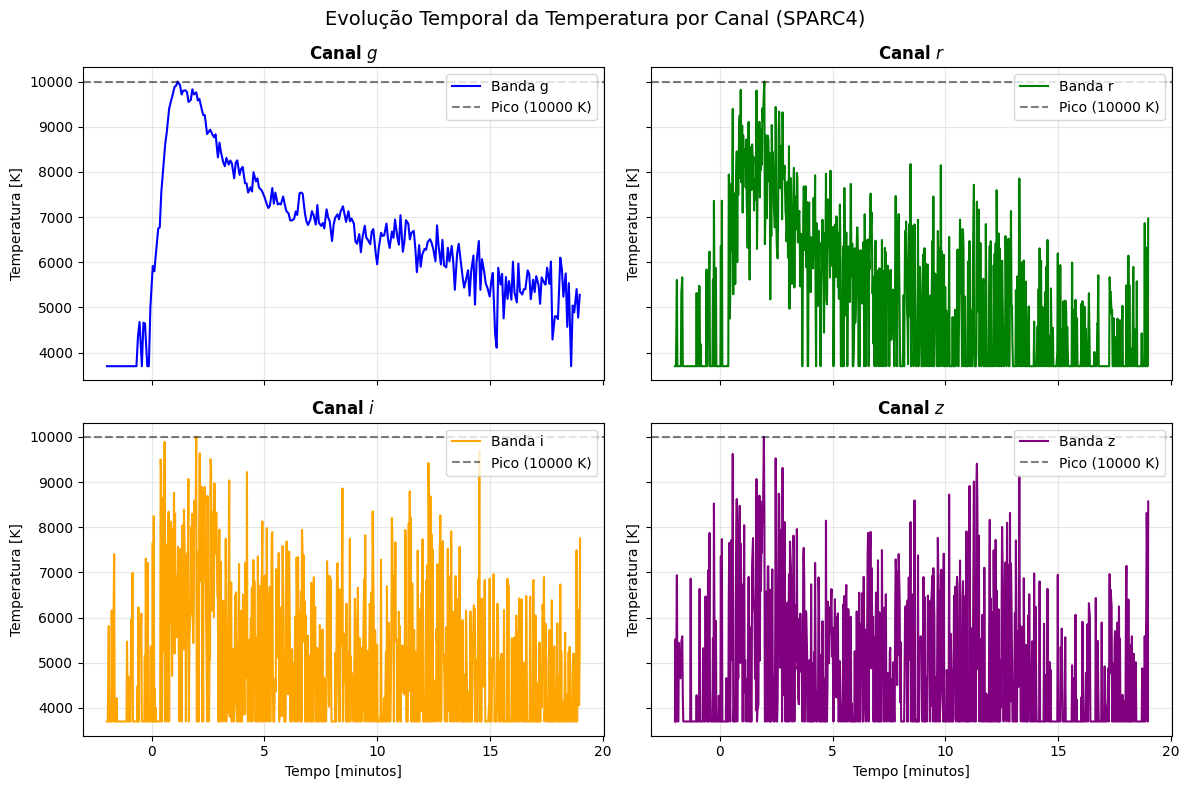

In [ ]:
# ==============================================================================
# 5. GRÁFICO DA TEMPERATURA SEPARADO POR CANAL (GRID 2x2)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()  # Facilita a iteração pelos 4 quadros (0 a 3)

cores = {"g": "blue", "r": "green", "i": "orange", "z": "purple"}

for idx, banda in enumerate(bandas):
    ax = axes_flat[idx]
    t_banda = resultados[banda]["t_min"]
    T_banda = resultados[banda]["T_t"]

    # Curva da temperatura do canal
    ax.plot(
        t_banda,
        T_banda,
        color=cores[banda],
        linewidth=1.5,
        label=f"Banda {banda}",
    )

    # Linha de referência do pico assumido (Tflare)
    ax.axhline(
        Tflare,
        color="black",
        linestyle="--",
        alpha=0.5,
        label=f"Pico ({Tflare} K)",
    )

    ax.set_title(f"Canal ${banda}$", fontsize=12, fontweight="bold")
    ax.set_ylabel("Temperatura [K]")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

# Rótulo do eixo X nos quadros da parte inferior
axes[1, 0].set_xlabel("Tempo [minutos]")
axes[1, 1].set_xlabel("Tempo [minutos]")

plt.suptitle(
    "Evolução Temporal da Temperatura por Canal (SPARC4)", fontsize=14
)
plt.tight_layout()
plt.show()

Banda  | Área Flare (m²)  | T Max (K)  | Energia (Joules) | Energia (Ergs) 
  g    |       7.7693e+14 |    10000.0 |      1.2723e+26 |      1.2723e+33
  r    |       1.2318e+15 |    10000.0 |      8.6583e+25 |      8.6583e+32
  i    |       1.3073e+15 |    10000.0 |      8.2910e+25 |      8.2910e+32
  z    |       2.2211e+15 |    10000.0 |      1.0069e+26 |      1.0069e+33


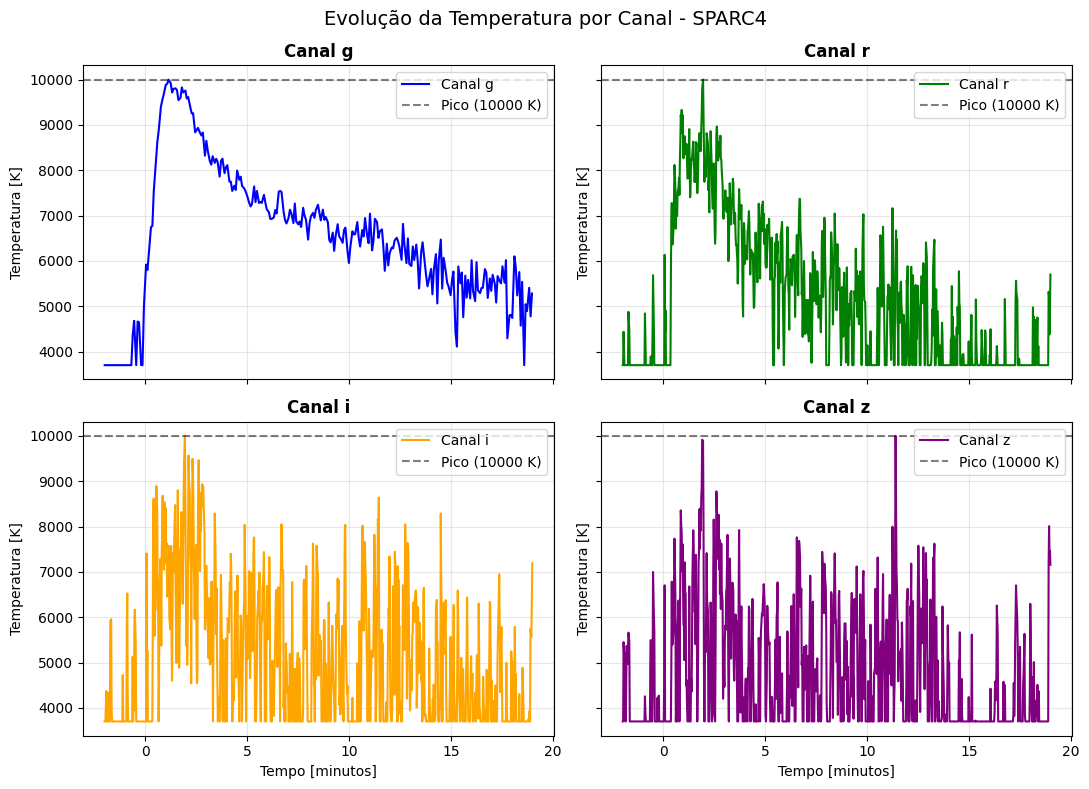

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson

# ==============================================================================
# 1. PARAMETROS GERAIS E RESPOSTA ESPECTRAL
# ==============================================================================
tf = pd.read_csv("data/sparc4_spectral_response.csv")
nm = np.array(tf["Wavelength (nm)"])

Teff = 3700  # Temperatura da estrela (K)
Tflare = 10000  # Temperatura de referência assumida no pico (K)
raio_estrela = 0.75 * 6.968e8  # Raio estelar (m)
Aestrela = np.pi * raio_estrela**2
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W / (m² K⁴)]
n = 264

bandas = ["g", "r", "i", "z"]

# ==============================================================================
# 2. SMOOTHING APENAS NAS BANDAS r, i, z (Janela de 3 pontos)
# ==============================================================================
janela = 3

a_r_sm = (
    pd.Series(a_r).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)
a_i_sm = (
    pd.Series(a_i).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)
a_z_sm = (
    pd.Series(a_z).rolling(window=janela, center=True, min_periods=1).mean().to_numpy()
)

# Mapeamento independente de fluxos e tempos por banda
curvas_luz = {"g": a_g, "r": a_r_sm, "i": a_i_sm, "z": a_z_sm}

tempos_minutos = {
    "g": t_g if "t_g" in locals() else t_z,
    "r": t_r if "t_r" in locals() else t_z,
    "i": t_i if "t_i" in locals() else t_z,
    "z": t_z,
}

# ==============================================================================
# 3. CÁLCULO DA ENERGIA INDEPENDENTE POR BANDA
# ==============================================================================
resultados = {}

for banda in bandas:
    y_banda = curvas_luz[banda]
    t_min = tempos_minutos[banda]
    t_seg = t_min * 60.0

    # Resposta espectral do filtro atual
    ry = np.array(tf[f"Channel {banda} (%)"]) / 100.0
    l_min, l_max = nm[ry > 0].min(), nm[ry > 0].max()
    wv_nm = np.linspace(l_min, l_max, n)
    wv_m = wv_nm * 1.0e-9
    R_banda = np.interp(wv_nm, nm, ry)

    # Trunca ruído negativo
    a_pos = np.maximum(y_banda, 0)
    amp_pico = np.max(a_pos)

    # Integrais de Planck (Equação 6)
    Bs = planck(Teff, lam=wv_m)
    Bf = planck(Tflare, lam=wv_m)

    int_Bs = simpson(Bs * R_banda, wv_m)
    int_diff = simpson((Bf - Bs) * R_banda, wv_m)

    # Área da flare calculada para esta banda
    A_flare = (amp_pico * Aestrela * int_Bs) / int_diff

    # Evolução da Temperatura T(t) (Equação 7)
    rhs_t = ((a_pos * Aestrela) / A_flare + 1.0) * int_Bs

    T_grid = np.linspace(2000, 25000, 1000)
    lhs_grid = np.array(
        [simpson(planck(T, lam=wv_m) * R_banda, wv_m) for T in T_grid]
    )

    T_flare_t = np.interp(rhs_t, lhs_grid, T_grid)

    # Luminosidade Excedente e Energia Total
    L_flare_t = np.where(
        y_banda > 0, sb1 * A_flare * (T_flare_t**4 - Teff**4), 0.0
    )

    E_flare_J = simpson(L_flare_t, t_seg)
    E_flare_erg = E_flare_J * 1.0e7

    # Salva resultados da banda
    resultados[banda] = {
        "A_flare": A_flare,
        "T_max": np.max(T_flare_t),
        "E_J": E_flare_J,
        "E_erg": E_flare_erg,
        "T_t": T_flare_t,
        "L_t": L_flare_t,
        "t_min": t_min,
    }

# ==============================================================================
# 4. EXIBIÇÃO DA TABELA DE RESULTADOS
# ==============================================================================
cabecalho = f"{'Banda':<6} | {'Área Flare (m²)':<16} | {'T Max (K)':<10} | {'Energia (Joules)':<15} | {'Energia (Ergs)':<15}"
print("=" * len(cabecalho))
print(cabecalho)
print("=" * len(cabecalho))

for banda, res in resultados.items():
    print(
        f"  {banda:<4} | {res['A_flare']:16.4e} | {res['T_max']:10.1f} |"
        f" {res['E_J']:15.4e} | {res['E_erg']:15.4e}"
    )

print("=" * len(cabecalho))

# ==============================================================================
# 5. GRÁFICO DA TEMPERATURA SEPARADO POR CANAL (GRID 2x2)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()
cores = {"g": "blue", "r": "green", "i": "orange", "z": "purple"}

for idx, banda in enumerate(bandas):
    ax = axes_flat[idx]
    t_b = resultados[banda]["t_min"]
    T_b = resultados[banda]["T_t"]

    ax.plot(
        t_b, T_b, color=cores[banda], linewidth=1.5, label=f"Canal {banda}"
    )
    ax.axhline(
        Tflare,
        color="black",
        linestyle="--",
        alpha=0.5,
        label=f"Pico ({Tflare} K)",
    )

    ax.set_title(f"Canal {banda}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Temperatura [K]")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

axes[1, 0].set_xlabel("Tempo [minutos]")
axes[1, 1].set_xlabel("Tempo [minutos]")

plt.suptitle("Evolução da Temperatura por Canal - SPARC4", fontsize=14)
plt.tight_layout()
plt.show()